In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split, Subset
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import torchvision.models as models

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)
import pickle
import tarfile
import os
import random
import copy
from collections import defaultdict
from collections import Counter
import pandas as pd
import optuna
from optuna.trial import TrialState
import warnings



warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


DATASET_PATH = "./dataset/cifar-10-python.tar.gz"
EXTRACT_PATH = "./cifar10_data"


Using device: cpu


# Image classification with convolutional network (CNN) and CIFAR-10 dataset

## Data preparation

Dataset already extracted.
Training data shape: (50000, 3, 32, 32)
Training labels shape: (50000,)
Test data shape: (10000, 3, 32, 32)
Test labels shape: (10000,)
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


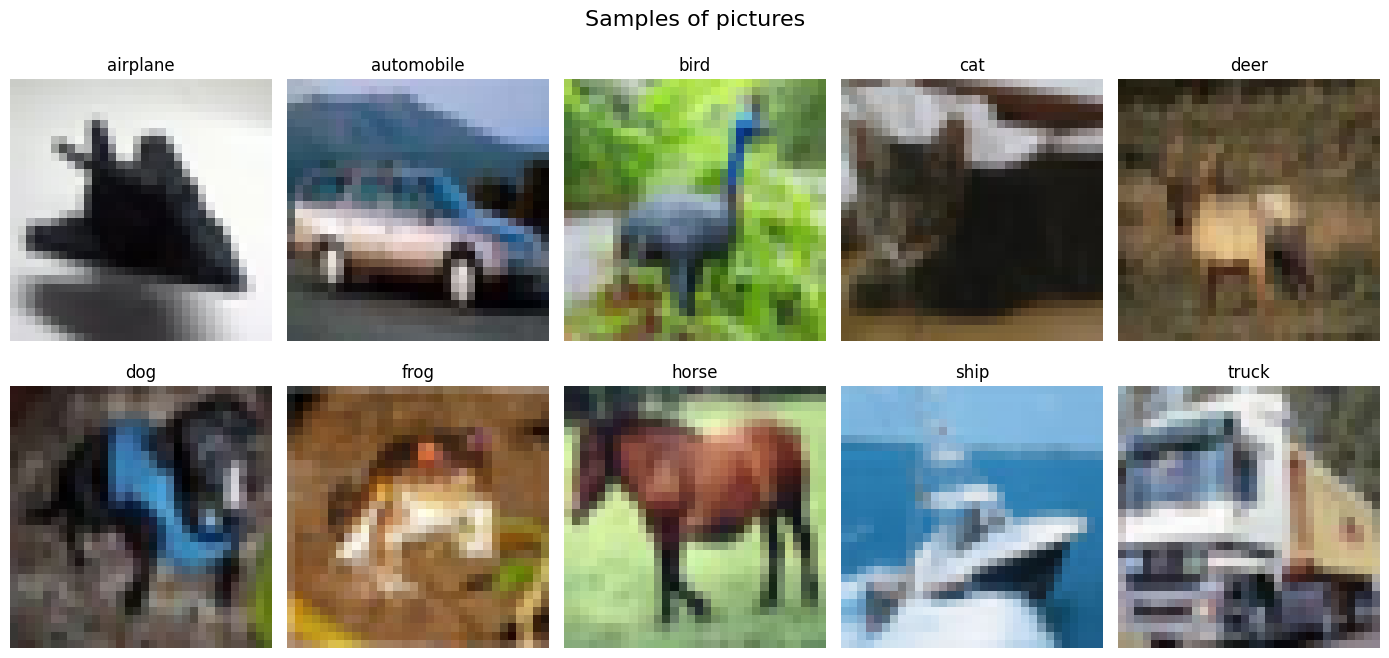

data distribution
     class  number of samples in train set percentage of samples in train set  number of samples in test set percentage of samples in test set
  airplane                            5000                              10.0%                           1000                             10.0%
automobile                            5000                              10.0%                           1000                             10.0%
      bird                            5000                              10.0%                           1000                             10.0%
       cat                            5000                              10.0%                           1000                             10.0%
      deer                            5000                              10.0%                           1000                             10.0%
       dog                            5000                              10.0%                           1000                

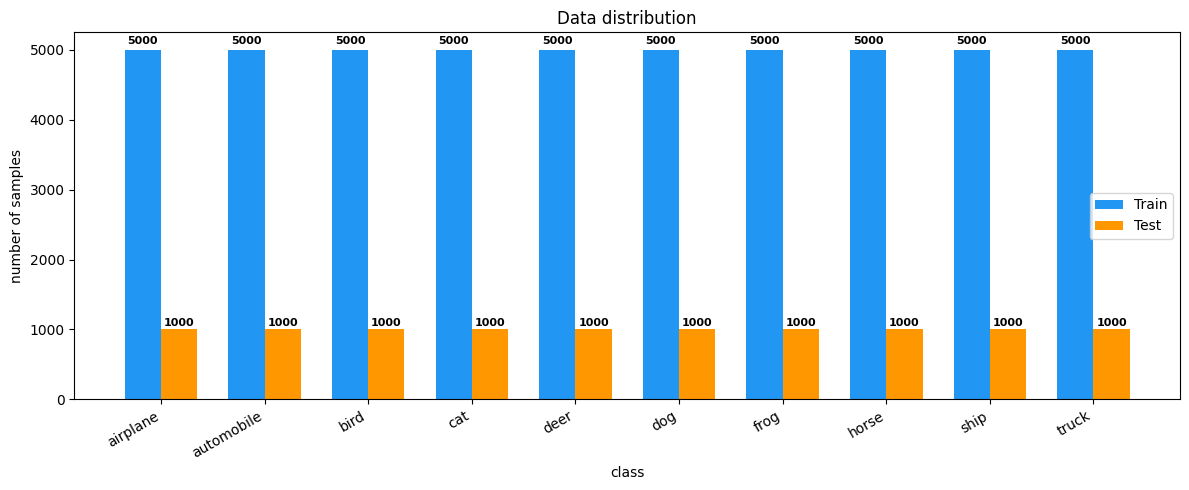

In [3]:
#extract data
if not os.path.exists(EXTRACT_PATH):
    os.makedirs(EXTRACT_PATH, exist_ok=True)
    with tarfile.open(DATASET_PATH, "r:gz") as tar:
        tar.extractall(path=EXTRACT_PATH)
    print("Dataset extracted.")
else:
    print("Dataset already extracted.")


def unpickle(file):
    with open(file, "rb") as fo:
        batch = pickle.load(fo, encoding="bytes")
    return batch


def load_cifar10_batches(data_dir):
    # train data
    train_images = []
    train_labels = []


    for i in range(1, 6):
        batch = unpickle(os.path.join(data_dir, f"data_batch_{i}"))
        train_images.append(batch[b"data"])
        train_labels.extend(batch[b"labels"])

    train_images = np.concatenate(train_images, axis=0)
    train_labels = np.array(train_labels)

 
    # test data
    test_batch = unpickle(os.path.join(data_dir, "test_batch"))
    test_images = test_batch[b"data"]
    test_labels = np.array(test_batch[b"labels"])


    train_images = train_images.reshape(-1, 3, 32, 32)
    test_images = test_images.reshape(-1, 3, 32, 32)


    train_images = train_images.astype(np.float32) / 255.0
    test_images = test_images.astype(np.float32) / 255.0

    return train_images, train_labels, test_images, test_labels



data_dir = os.path.join(EXTRACT_PATH, "cifar-10-batches-py")
X_train_full, y_train_full, X_test, y_test = load_cifar10_batches(data_dir)

print(f"Training data shape: {X_train_full.shape}")
print(f"Training labels shape: {y_train_full.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")


meta = unpickle(os.path.join(data_dir, "batches.meta"))
class_names = [label.decode("utf-8") for label in meta[b"label_names"]]
print(f"Classes: {class_names}")


# plotting pictures from each class
fig, axes = plt.subplots(2, 5, figsize=(14, 7))
axes = axes.flatten()

for i, class_name in enumerate(class_names):
    idx = np.where(y_train_full == i)[0][0]
    img = X_train_full[idx].transpose(1, 2, 0)  # C,H,W -> H,W,C
    axes[i].imshow(img)
    axes[i].set_title(class_name)
    axes[i].axis("off")

plt.suptitle("Samples of pictures", fontsize=16)
plt.tight_layout()
plt.show()



train_counter = Counter(y_train_full)
test_counter = Counter(y_test)

df_distribution = pd.DataFrame({
    "class": class_names,
    "number of samples in train set": [train_counter[i] for i in range(10)],
    "percentage of samples in train set": [f"{train_counter[i] / len(y_train_full) * 100:.1f}%" for i in range(10)],
    "number of samples in test set": [test_counter[i] for i in range(10)],
    "percentage of samples in test set": [f"{test_counter[i] / len(y_test) * 100:.1f}%" for i in range(10)],
})

print("data distribution")
print(df_distribution.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(class_names))
width = 0.35

bars_train = ax.bar(x - width/2, [train_counter[i] for i in range(10)], width, label="Train", color="#2196F3")
bars_test  = ax.bar(x + width/2, [test_counter[i] for i in range(10)], width, label="Test", color="#FF9800")

ax.set_xlabel("class")
ax.set_ylabel("number of samples")
ax.set_title("Data distribution")
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha="right")
ax.legend()

for bar in bars_train:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, str(int(bar.get_height())),
            ha="center", va="bottom", fontsize=8, fontweight="bold")
for bar in bars_test:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(int(bar.get_height())),
            ha="center", va="bottom", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()


### Analysis
As can be seen, due to the small size of the images, the quality is not very good and sometimes it may be difficult for humans to distinguish the image class, for example between a dog and a cat or a deer.
Also, the classes in the dataset are balanced and we have an equal number of samples from each class in the train and test sets.

In [4]:
class CIFAR10Dataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = torch.tensor(images, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label


# computing mean and std for normalization
mean = (X_train_full.mean(axis=(0, 2, 3)),)
std = (X_train_full.std(axis=(0, 2, 3)),)
print(f"Mean (per channel): {X_train_full.mean(axis=(0, 2, 3))}")
print(f"Std (per channel): {X_train_full.std(axis=(0, 2, 3))}")


# normalization
basic_transform = transforms.Compose(
    [
        transforms.Normalize(
            mean=X_train_full.mean(axis=(0, 2, 3)),
            std=X_train_full.std(axis=(0, 2, 3)),
        )
    ]
)


full_dataset = CIFAR10Dataset(X_train_full, y_train_full, transform=basic_transform)
test_dataset = CIFAR10Dataset(X_test, y_test, transform=basic_transform)

train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}, Test samples: {len(test_dataset)}")


Mean (per channel): [0.4914009  0.48215896 0.4465308 ]
Std (per channel): [0.24703279 0.24348423 0.26158753]
Train samples: 45000, Validation samples: 5000, Test samples: 10000


## Section1 - Classification with CNNs

### Implementing CNN model

In [5]:

class CIFAR10_CNN(nn.Module):

    def __init__(self, dropout_rate=0.3, num_classes=10):
        super(CIFAR10_CNN, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 32x32 -> 16x16
        )

     
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 16x16 -> 8x8
        )


        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 8x8 -> 4x4
        )


        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((2, 2)),  # 4x4 -> 2x2
        )

        # Fully Connected
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 2 * 2, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate / 2),
            nn.Linear(128, num_classes),
        )

     
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.fc(x)
        return x



model_base = CIFAR10_CNN(dropout_rate=0.3).to(device)
print(model_base)
print(f"\nTotal parameters: {sum(p.numel() for p in model_base.parameters()):,}")



CIFAR10_CNN(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2

### Training model

In [6]:
def train_model1(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def train_model2(
    model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, device, model_name="model"
):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = 0.0
    best_model_state = None

    for epoch in range(num_epochs):
        train_loss, train_acc = train_model1(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        if scheduler:
            scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())

        print(
            f"Epoch [{epoch+1:3d}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

   # loading best parameters
    model.load_state_dict(best_model_state)
    print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")
    return model, history, best_val_acc


In [7]:

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_base.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)
NUM_EPOCHS = 30

print("Train configurations:")
print(f"- Optimizer: AdamW (lr=0.001, weight_decay=1e-4)")
print(f"- Loss: CrossEntropyLoss")
print(f"- Epochs: {NUM_EPOCHS}")
print(f"- Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")
print(f"- Batch Size: {BATCH_SIZE}")

model_base, history_base, best_val_acc_base = train_model2(
    model_base, train_loader, val_loader, criterion, optimizer, scheduler, NUM_EPOCHS, device, "CNN_Base"
)


Train configurations:
- Optimizer: AdamW (lr=0.001, weight_decay=1e-4)
- Loss: CrossEntropyLoss
- Epochs: 30
- Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)
- Batch Size: 64
Epoch [  1/30] Train Loss: 1.3393 | Train Acc: 0.5186 | Val Loss: 1.5118 | Val Acc: 0.5148
Epoch [  2/30] Train Loss: 0.8821 | Train Acc: 0.6983 | Val Loss: 0.8431 | Val Acc: 0.7060
Epoch [  3/30] Train Loss: 0.7096 | Train Acc: 0.7589 | Val Loss: 0.7980 | Val Acc: 0.7282
Epoch [  4/30] Train Loss: 0.5976 | Train Acc: 0.8000 | Val Loss: 0.6452 | Val Acc: 0.7784
Epoch [  5/30] Train Loss: 0.5049 | Train Acc: 0.8316 | Val Loss: 0.6813 | Val Acc: 0.7824
Epoch [  6/30] Train Loss: 0.4240 | Train Acc: 0.8580 | Val Loss: 0.6094 | Val Acc: 0.7942
Epoch [  7/30] Train Loss: 0.3615 | Train Acc: 0.8789 | Val Loss: 0.5943 | Val Acc: 0.8100
Epoch [  8/30] Train Loss: 0.3101 | Train Acc: 0.8950 | Val Loss: 0.6058 | Val Acc: 0.8144
Epoch [  9/30] Train Loss: 0.2621 | Train Acc: 0.9122 | Val Loss: 0.5459 | Val Acc: 0.8330



The architecture CIFAR10_CNN follows a VGG-inspired, modular design with four convolutional blocks followed by a fully connected classifier.
+ Spatial resolution decreases while channel depth increases, following the established paradigm of convolutional architectures.
+ Two consecutive $3 \times 3$ convolutions per block — each pair effectively yields a $5 \times 5$ receptive field but with fewer parameters and more non-linearity than a single $5 \times 5$ filter.
+ BatchNorm after every convolution Improves training stability, allows higher learning rates, and provides implicit regularization.

---

### Activation Function: ReLU 

Why ReLU over alternatives?

- inplace=True: Saves memory by modifying the tensor in-place rather than allocating new memory for the output. Critical for training on CPU/limited GPU.
- Non-saturating: Gradient is constant (1) for all positive inputs, preventing vanishing gradients in deep networks.
---

### Batch Normalization (BN)

Applied before ReLU in each conv block:

$$ \hat{x} = \frac{x - \mu_B}{\sqrt{\sigma^2_B + \epsilon}}, \quad y = \gamma \hat{x} + \beta $$

BN is used because it causes:

1. Internal Covariate Shift reduction: Normalizing each mini-batch stabilizes the distribution of inputs to each layer, allowing higher learning rates.
2. Smoother optimization landscape: BN makes the loss surface significantly smoother, enabling faster convergence with less sensitivity to initialization.
3. Implicit regularization: The stochasticity of mini-batch statistics adds noise, reducing the need for explicit regularization (like Dropout) in convolutional layers.
4. Scale invariance: BN makes the network robust to weight scale, preventing exploding/vanishing activations.

---

### Weight Initialization Strategy

#### Kaiming Normal for Convolutions
When using ReLU activation, the variance of forward activations would otherwise grow exponentially with depth. Kaiming initialization solves this problem.

`mode="fan_out"` preserves variance in the **forward** pass (important since we use ReLU after each convolution).

#### Xavier Normal for Linear Layers

For the classifier, Xavier initialization balances forward and backward variance for layers without non-linearities nearby.

#### Bias = 0

With BatchNorm, biases in convolutional layers are redundant (BN's $\beta$ already shifts the distribution). Setting them to zero avoids unnecessary parameters.

---


### Optimizer: AdamW

#### Adam

Adam maintains two moving averages:
- $m_t$: first moment (mean of gradients) — momentum
- $v_t$: second moment (variance) — adaptive learning rate

$$ m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t $$
$$ v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2 $$
$$ \theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t $$

#### AdamW (Decoupled Weight Decay) 

In standard Adam, $L_2$ regularization (weight decay) is implemented by adding $\lambda \theta$ to the gradient **before** moment accumulation. This means parameters with small gradient magnitudes (low $\hat{v}_t$) experience **stronger** regularization, which is counterproductive — those are precisely the parameters that haven't been updated much and need freedom to move.

AdamW applies weight decay **directly** to the parameters:

$$ \theta_{t+1} = \theta_t - \eta \left(\frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} + \lambda \theta_t \right) $$

This **decouples** regularization from adaptation, yielding:
- Better generalization
- Consistent regularization regardless of gradient history
- Hyperparameter independence: The optimal learning rate and weight decay are now independent, making tuning easier

---

### Loss Function: Cross-Entropy

It is a formal loss function for classification.

---

### Learning Rate Scheduler: ReduceLROnPlateau

Monitors validation loss. If no improvement is seen for `patience` epochs, reduces learning rate:

$$ \eta_{\text{new}} = \eta_{\text{old}} \times \text{factor} $$
---

### Evaluating model

Test Loss: 1.1978 | Test Accuracy: 0.8460


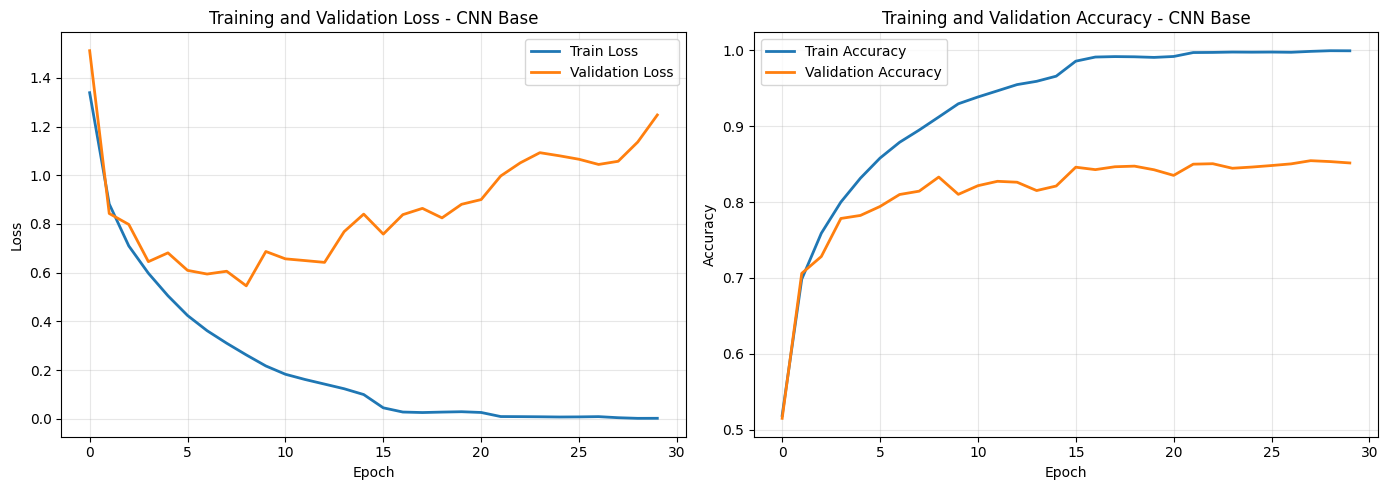

In [8]:
test_loss_base, test_acc_base = evaluate(model_base, test_loader, criterion, device)
print(f"Test Loss: {test_loss_base:.4f} | Test Accuracy: {test_acc_base:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Loss
axes[0].plot(history_base["train_loss"], label="Train Loss", linewidth=2)
axes[0].plot(history_base["val_loss"], label="Validation Loss", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training and Validation Loss - CNN Base")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history_base["train_acc"], label="Train Accuracy", linewidth=2)
axes[1].plot(history_base["val_acc"], label="Validation Accuracy", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training and Validation Accuracy - CNN Base")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Analysis
According to the graphs above, we can say that from around epoch 8 onwards, the model has started to overfit because the training loss has always decreased until it reached near zero, but the validation loss has started to increase. The highest accuracy of the model on the validation set also occurred around epoch 20.

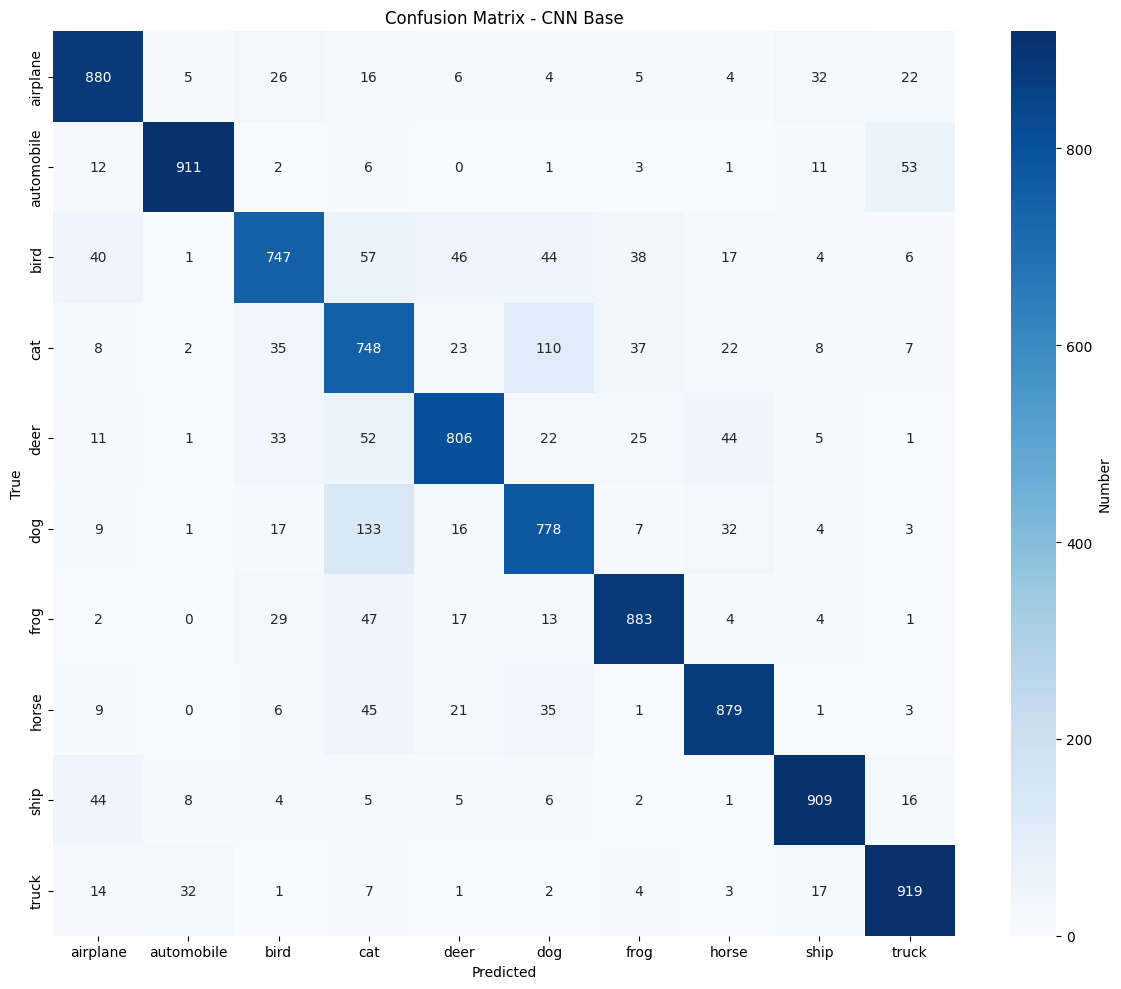

Class              Precision       Recall     F1-Score
airplane              0.8552       0.8800       0.8674
automobile            0.9480       0.9110       0.9291
bird                  0.8300       0.7470       0.7863
cat                   0.6703       0.7480       0.7070
deer                  0.8565       0.8060       0.8305
dog                   0.7665       0.7780       0.7722
frog                  0.8786       0.8830       0.8808
horse                 0.8729       0.8790       0.8759
ship                  0.9136       0.9090       0.9113
truck                 0.8914       0.9190       0.9050

Macro Avg             0.8483       0.8460       0.8466


In [9]:
def get_predictions(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)

y_pred_base, y_true_base = get_predictions(model_base, test_loader, device)


# Confusion Matrix
cm = confusion_matrix(y_true_base, y_pred_base)
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={"label": "Number"},
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - CNN Base")
plt.tight_layout()
plt.show()

# Precision, Recall, F1
precision = precision_score(y_true_base, y_pred_base, average=None)
recall = recall_score(y_true_base, y_pred_base, average=None)
f1 = f1_score(y_true_base, y_pred_base, average=None)

print(f"{'Class':<15} {'Precision':>12} {'Recall':>12} {'F1-Score':>12}")

for i, name in enumerate(class_names):
    print(f"{name:<15} {precision[i]:>12.4f} {recall[i]:>12.4f} {f1[i]:>12.4f}")

print(f"\n{'Macro Avg':<15} {precision.mean():>12.4f} {recall.mean():>12.4f} {f1.mean():>12.4f}")


### Analysis
According to the confusion matrix above, it can be seen that, for example, an airplane was mistaken for these two classes due to its appearance similarity to a bird or sometimes a ship. Similarly, a car and a truck or a horse and a deer or a dog and a cat were misidentified due to their general similarity and the fact that the images were not of high enough resolution and quality to distinguish the differences between these pairs of classes.
The classes with the lowest F1 score, such as cat and dog and bird, were classified more difficultly.

### Preventing overfitting

In [10]:
class CIFAR10_CNN2(nn.Module):

    def __init__(self, dropout_rate=0.4, num_classes=10): # I increase dropout probability to prevent overfitting
        super(CIFAR10_CNN2, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.15),   # I use dropout in Conv blocks to prevent overfitting
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2),
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25),
        )

        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((2, 2)),
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 2 * 2, 512),
            nn.BatchNorm1d(512),    # I use BN here in FC layers because it has a low regularization effect
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.75),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.5),
            nn.Linear(128, num_classes),
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d) or isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.fc(x)
        return x

CIFAR10_CNN2(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.15, inplace=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)

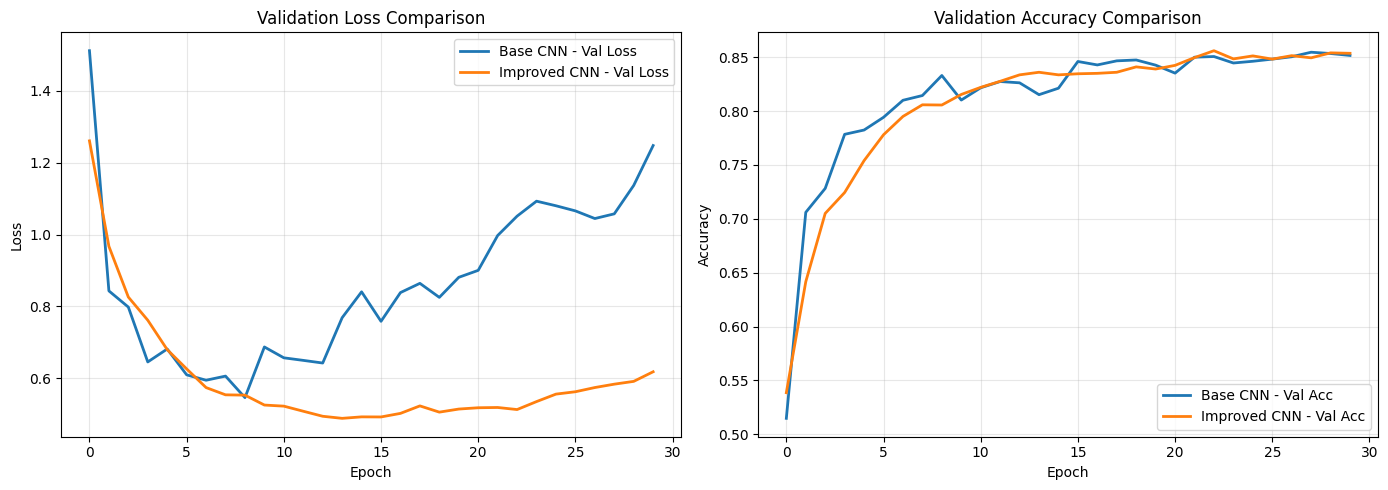

In [11]:
model_improved = CIFAR10_CNN2(dropout_rate=0.4).to(device)
print(model_improved)
print(f"\nTotal parameters: {sum(p.numel() for p in model_improved.parameters()):,}")

criterion_imp = nn.CrossEntropyLoss()
optimizer_imp = optim.AdamW(model_improved.parameters(), lr=0.001, weight_decay=5e-4)  # I use a larger L2 regularization coefficient to prevent overfitting
scheduler_imp = optim.lr_scheduler.ReduceLROnPlateau(optimizer_imp, mode="min", factor=0.5, patience=5)


model_improved, history_improved, best_val_improved = train_model2(
    model_improved, train_loader, val_loader, criterion_imp, optimizer_imp, scheduler_imp, NUM_EPOCHS, device, "CNN_Improved"
)

# comparison
test_loss_imp, test_acc_imp = evaluate(model_improved, test_loader, criterion_imp, device)
print(f"\nImpooved CNN- Test Loss: {test_loss_imp:.4f} | Test Accuracy: {test_acc_imp:.4f}")



fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_base["val_loss"], label="Base CNN - Val Loss", linewidth=2)
axes[0].plot(history_improved["val_loss"], label="Improved CNN - Val Loss", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Validation Loss Comparison")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history_base["val_acc"], label="Base CNN - Val Acc", linewidth=2)
axes[1].plot(history_improved["val_acc"], label="Improved CNN - Val Acc", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Validation Accuracy Comparison")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Analysis
The architecture of the two models is the same except for the fully connected layers, but to prevent overfitting of the model, dropout has been added in the convolution layers along with batch normalization. Batch normalization has also been used in the fully connected layers, which has a slight regularization effect. The probability of dropout has also increased in these layers. The L2 regularization coefficient has also been increased compared to the previous model to prevent overfitting.

The two models show a clear difference in generalization behavior. The baseline CNN (without regularization) achieves competitive validation accuracy early on, but its validation loss starts to rise noticeably after roughly the first third of training. This is a sign of overfitting, the model continues to fit the training data better, but its performance on unseen validation data degrades. In contrast, the improved CNN with regularization shows a much smoother and more stable validation-loss curve. Its loss drops steadily, reaches a lower minimum, and remains significantly lower than the baseline model for the rest of training, indicating better control over model complexity.

In terms of validation accuracy, both models eventually converge to a similar final range of about 0.85–0.86, but the regularized model does so with less instability and a much better loss profile. This is important because accuracy alone can hide calibration and confidence issues, whereas validation loss reflects the quality of the predicted probabilities.

### Data augmentation

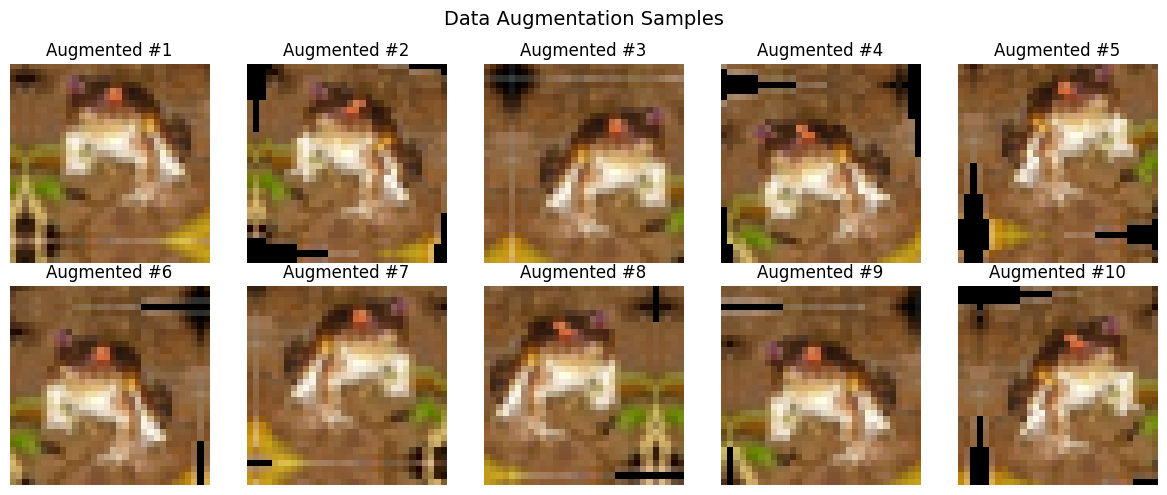

In [10]:
augmentation_transform = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.RandomCrop(size=32, padding=4, padding_mode="reflect"),
        transforms.Normalize(
            mean=X_train_full.mean(axis=(0, 2, 3)),
            std=X_train_full.std(axis=(0, 2, 3)),
        ),
    ]
)


train_dataset_aug = CIFAR10Dataset(X_train_full, y_train_full, transform=augmentation_transform)

val_dataset_full = CIFAR10Dataset(X_train_full, y_train_full, transform=basic_transform)


train_size_aug = int(0.9 * len(train_dataset_aug))
val_size_aug = len(train_dataset_aug) - train_size_aug


indices = list(range(len(train_dataset_aug)))
random.Random(SEED).shuffle(indices)
train_indices = indices[:train_size_aug]
val_indices = indices[train_size_aug:]

train_dataset_aug_final = Subset(train_dataset_aug, train_indices)
val_dataset_aug_final = Subset(val_dataset_full, val_indices)

train_loader_aug = DataLoader(train_dataset_aug_final, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader_aug = DataLoader(val_dataset_aug_final, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


# showing augmented pictures
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()
test_img = X_train_full[0] 
test_img_tensor = torch.tensor(test_img, dtype=torch.float32)


mean_arr = X_train_full.mean(axis=(0, 2, 3))
std_arr = X_train_full.std(axis=(0, 2, 3))

for i in range(10):
    augmented = augmentation_transform(test_img_tensor)
    # Denormalize
    img_disp = augmented.clone()
    for c in range(3):
        img_disp[c] = img_disp[c] * std_arr[c] + mean_arr[c]
    img_disp = torch.clamp(img_disp, 0, 1)
    axes[i].imshow(img_disp.permute(1, 2, 0).numpy())
    axes[i].set_title(f"Augmented #{i+1}")
    axes[i].axis("off")

plt.suptitle("Data Augmentation Samples", fontsize=14)
plt.tight_layout()
plt.show()

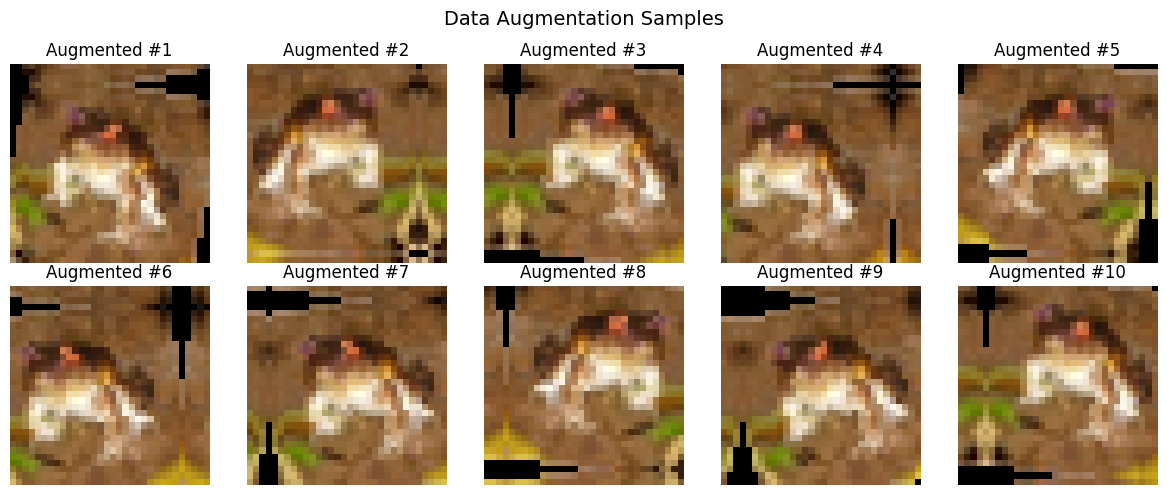

Training with data augmentation:
Epoch [  1/30] Train Loss: 1.8524 | Train Acc: 0.3201 | Val Loss: 1.4628 | Val Acc: 0.4710
Epoch [  2/30] Train Loss: 1.5369 | Train Acc: 0.4377 | Val Loss: 1.2248 | Val Acc: 0.5522
Epoch [  3/30] Train Loss: 1.3660 | Train Acc: 0.5100 | Val Loss: 1.0626 | Val Acc: 0.6180
Epoch [  4/30] Train Loss: 1.2546 | Train Acc: 0.5500 | Val Loss: 0.9718 | Val Acc: 0.6568
Epoch [  5/30] Train Loss: 1.1644 | Train Acc: 0.5895 | Val Loss: 0.9050 | Val Acc: 0.6744
Epoch [  6/30] Train Loss: 1.0918 | Train Acc: 0.6170 | Val Loss: 0.8093 | Val Acc: 0.7094
Epoch [  7/30] Train Loss: 1.0271 | Train Acc: 0.6420 | Val Loss: 0.7460 | Val Acc: 0.7286
Epoch [  8/30] Train Loss: 0.9738 | Train Acc: 0.6634 | Val Loss: 0.7412 | Val Acc: 0.7346
Epoch [  9/30] Train Loss: 0.9349 | Train Acc: 0.6760 | Val Loss: 0.7133 | Val Acc: 0.7444
Epoch [ 10/30] Train Loss: 0.9003 | Train Acc: 0.6876 | Val Loss: 0.6379 | Val Acc: 0.7706
Epoch [ 11/30] Train Loss: 0.8689 | Train Acc: 0.7006 | V

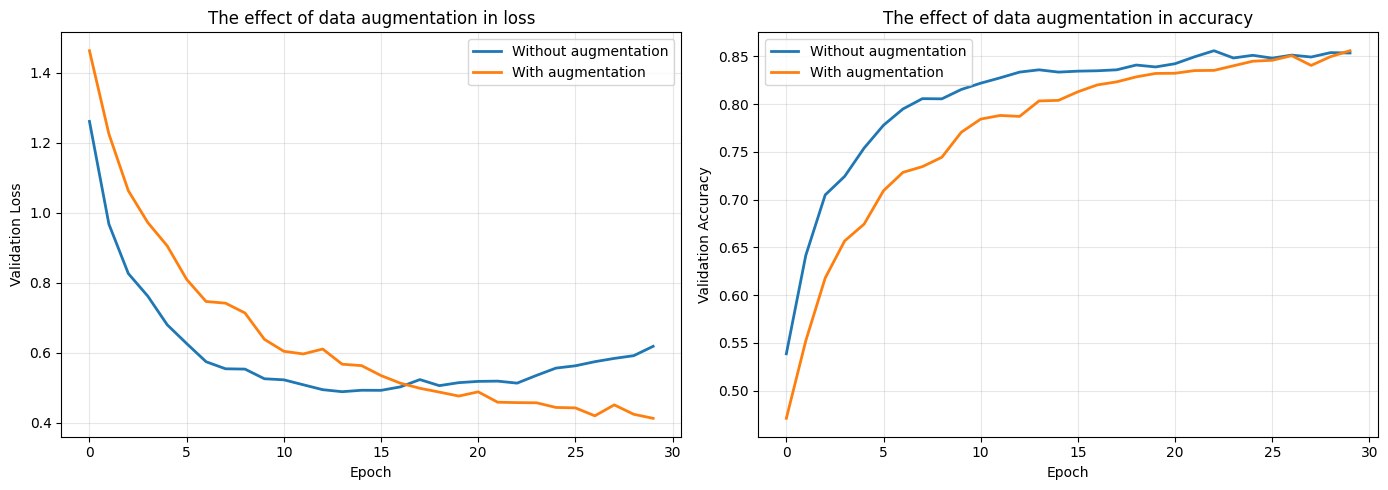

In [ ]:
model_aug = CIFAR10_CNN2(dropout_rate=0.35).to(device)  # I reduce dropout_rate because using data augmentation has regularization effect

criterion_aug = nn.CrossEntropyLoss()
optimizer_aug = optim.AdamW(model_aug.parameters(), lr=0.001, weight_decay=3e-4)
scheduler_aug = optim.lr_scheduler.ReduceLROnPlateau(optimizer_aug, mode="min", factor=0.5, patience=7)

print("Training with data augmentation:")
model_aug, history_aug, best_val_aug = train_model2(
    model_aug, train_loader_aug, val_loader_aug, criterion_aug, optimizer_aug, scheduler_aug, NUM_EPOCHS, device, "CNN_Augmented"
)


test_loss_aug, test_acc_aug = evaluate(model_aug, test_loader, criterion_aug, device)
print(f"\nTest Loss: {test_loss_aug:.4f} | Test Accuracy: {test_acc_aug:.4f}")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_improved["val_loss"], label="Without augmentation", linewidth=2)
axes[0].plot(history_aug["val_loss"], label="With augmentation", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation Loss")
axes[0].set_title("The effect of data augmentation in loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_improved["val_acc"], label="Without augmentation", linewidth=2)
axes[1].plot(history_aug["val_acc"], label="With augmentation", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Accuracy")
axes[1].set_title("The effect of data augmentation in accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Analysis
According to the above graphs, we can see that the loss on the validation set with augmented data has always decreased, while the same model without augmented data has started to overfit faster. In this section, both models were of the second type (model with regularization), but the same model with augmented data has overfitted less and its accuracy on the validation set has been as good as training without augmented data, while the accuracy on the training set is much lower. If the model with augmented data is trained for more epochs, the accuracy of training and validation may increase even more.

### Hyperparameter tuning

In [12]:
SUBSET_SIZE = 15000
indices_subset = random.sample(range(len(train_dataset_aug)), min(SUBSET_SIZE, len(train_dataset_aug)))
train_subset = Subset(train_dataset_aug, indices_subset)
train_loader_optuna = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

val_subset_size = 3000
val_indices_subset = random.sample(val_indices, min(val_subset_size, len(val_indices)))
val_subset = Subset(val_dataset_full, val_indices_subset)
val_loader_optuna = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


def create_model_for_optuna(trial):

    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.6)
    num_filters_base = trial.suggest_int("num_filters_base", 16, 48, step=8)  # number of filters in first layer 

    class DynamicCNN(nn.Module):
        def __init__(self):
            super(DynamicCNN, self).__init__()
            f1 = num_filters_base   # to prevent large number of hyperparameters I tune number of filters in first layer and The number of filters in subsequent layers is twice the number of filters in the previous layer.
            f2 = num_filters_base * 2
            f3 = num_filters_base * 4
            f4 = num_filters_base * 8

            self.conv1 = nn.Sequential(
                nn.Conv2d(3, f1, 3, padding=1),
                nn.BatchNorm2d(f1),
                nn.ReLU(inplace=True),
                nn.Conv2d(f1, f1, 3, padding=1),
                nn.BatchNorm2d(f1),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
                nn.Dropout2d(0.1),
            )
            self.conv2 = nn.Sequential(
                nn.Conv2d(f1, f2, 3, padding=1),
                nn.BatchNorm2d(f2),
                nn.ReLU(inplace=True),
                nn.Conv2d(f2, f2, 3, padding=1),
                nn.BatchNorm2d(f2),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
                nn.Dropout2d(0.15),
            )
            self.conv3 = nn.Sequential(
                nn.Conv2d(f2, f3, 3, padding=1),
                nn.BatchNorm2d(f3),
                nn.ReLU(inplace=True),
                nn.Conv2d(f3, f3, 3, padding=1),
                nn.BatchNorm2d(f3),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
                nn.Dropout2d(0.2),
            )
            self.conv4 = nn.Sequential(
                nn.Conv2d(f3, f4, 3, padding=1),
                nn.BatchNorm2d(f4),
                nn.ReLU(inplace=True),
                nn.AdaptiveAvgPool2d((2, 2)),
            )
            self.fc = nn.Sequential(
                nn.Flatten(),
                nn.Linear(f4 * 4, 256),
                nn.BatchNorm1d(256),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout_rate),
                nn.Linear(256, 128),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout_rate / 2),
                nn.Linear(128, 10),
            )

        def forward(self, x):
            x = self.conv1(x)
            x = self.conv2(x)
            x = self.conv3(x)
            x = self.conv4(x)
            x = self.fc(x)
            return x

    return DynamicCNN()


def objective(trial):

    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True) # log scale search for lr
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)

    train_loader_trial = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)


    model = create_model_for_optuna(trial).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # training for 5 epoch (for speed)
    for epoch in range(5):
        model.train()
        for images, labels in train_loader_trial:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # evaluation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader_optuna:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    accuracy = correct / total
    return accuracy



N_TRIALS = 5

study = optuna.create_study(
    direction="maximize",
    study_name="cifar10_cnn_optimization",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)


print(f"Best trial: #{study.best_trial.number}")
print(f"Best validation accuracy: {study.best_value:.4f}")
print("\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")


# optuna.visualization.matplotlib.plot_param_importances(study)
# plt.title("Hyperparameter Importances")
# plt.tight_layout()
# plt.show()

# optuna.visualization.matplotlib.plot_optimization_history(study)
# plt.title("Optimization History")
# plt.tight_layout()
# plt.show()


[I 2026-05-31 04:23:56,150] A new study created in memory with name: cifar10_cnn_optimization
Best trial: 0. Best value: 0.582333:  20%|██        | 1/5 [00:58<03:53, 58.31s/it]

[I 2026-05-31 04:24:54,454] Trial 0 finished with value: 0.5823333333333334 and parameters: {'lr': 0.0005611516415334506, 'batch_size': 32, 'weight_decay': 2.0513382630874486e-05, 'dropout_rate': 0.26239780813448105, 'num_filters_base': 16}. Best is trial 0 with value: 0.5823333333333334.


Best trial: 0. Best value: 0.582333:  40%|████      | 2/5 [02:33<04:00, 80.15s/it]

[I 2026-05-31 04:26:29,889] Trial 1 finished with value: 0.5063333333333333 and parameters: {'lr': 0.005399484409787433, 'batch_size': 64, 'weight_decay': 0.0008706020878304854, 'dropout_rate': 0.5329770563201687, 'num_filters_base': 24}. Best is trial 0 with value: 0.5823333333333334.


Best trial: 2. Best value: 0.612:  60%|██████    | 3/5 [05:36<04:14, 127.06s/it]  

[I 2026-05-31 04:29:32,788] Trial 2 finished with value: 0.612 and parameters: {'lr': 0.0002310201887845295, 'batch_size': 128, 'weight_decay': 7.309539835912905e-05, 'dropout_rate': 0.31649165607921675, 'num_filters_base': 40}. Best is trial 2 with value: 0.612.


Best trial: 2. Best value: 0.612:  80%|████████  | 4/5 [07:42<02:06, 126.42s/it]

[I 2026-05-31 04:31:38,209] Trial 3 finished with value: 0.5866666666666667 and parameters: {'lr': 0.00019010245319870352, 'batch_size': 128, 'weight_decay': 0.00037183641805732076, 'dropout_rate': 0.2798695128633439, 'num_filters_base': 32}. Best is trial 2 with value: 0.612.


Best trial: 2. Best value: 0.612: 100%|██████████| 5/5 [11:29<00:00, 137.99s/it]

[I 2026-05-31 04:35:26,078] Trial 4 finished with value: 0.601 and parameters: {'lr': 0.0015304852121831463, 'batch_size': 64, 'weight_decay': 1.3492834268013232e-05, 'dropout_rate': 0.5795542149013333, 'num_filters_base': 48}. Best is trial 2 with value: 0.612.
Best trial: #2
Best validation accuracy: 0.6120

Best hyperparameters:
  lr: 0.0002310201887845295
  batch_size: 128
  weight_decay: 7.309539835912905e-05
  dropout_rate: 0.31649165607921675
  num_filters_base: 40


Unfortunately my laptop crashes for more trials.

In [13]:
best_params = study.best_params

class BestCNN(nn.Module):
    def __init__(self, num_filters_base, dropout_rate):
        super(BestCNN, self).__init__()
        f1, f2, f3, f4 = num_filters_base, num_filters_base * 2, num_filters_base * 4, num_filters_base * 8

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, f1, 3, padding=1), nn.BatchNorm2d(f1), nn.ReLU(inplace=True),
            nn.Conv2d(f1, f1, 3, padding=1), nn.BatchNorm2d(f1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(0.1),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(f1, f2, 3, padding=1), nn.BatchNorm2d(f2), nn.ReLU(inplace=True),
            nn.Conv2d(f2, f2, 3, padding=1), nn.BatchNorm2d(f2), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(0.15),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(f2, f3, 3, padding=1), nn.BatchNorm2d(f3), nn.ReLU(inplace=True),
            nn.Conv2d(f3, f3, 3, padding=1), nn.BatchNorm2d(f3), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(f3, f4, 3, padding=1), nn.BatchNorm2d(f4), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((2, 2)),
        )
        self.fc = nn.Sequential(
            nn.Flatten(), nn.Linear(f4 * 4, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate), nn.Linear(256, 128), nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate / 2), nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.conv1(x); x = self.conv2(x); x = self.conv3(x); x = self.conv4(x); x = self.fc(x)
        return x


model_best = BestCNN(best_params["num_filters_base"], best_params["dropout_rate"]).to(device)
criterion_best = nn.CrossEntropyLoss()
optimizer_best = optim.AdamW(model_best.parameters(), lr=best_params["lr"], weight_decay=best_params["weight_decay"])
scheduler_best = optim.lr_scheduler.ReduceLROnPlateau(optimizer_best, mode="min", factor=0.5, patience=5)

# training on whole augmented data
train_loader_best = DataLoader(train_dataset_aug, batch_size=best_params["batch_size"],
                                shuffle=True, num_workers=2, pin_memory=True)

model_best, history_best, _ = train_model2(
    model_best, train_loader_best, val_loader, criterion_best, optimizer_best, scheduler_best, 30, device, "BestCNN"
)



Epoch [  1/30] Train Loss: 1.6764 | Train Acc: 0.3884 | Val Loss: 1.2052 | Val Acc: 0.5596
Epoch [  2/30] Train Loss: 1.3283 | Train Acc: 0.5216 | Val Loss: 0.9787 | Val Acc: 0.6492
Epoch [  3/30] Train Loss: 1.1645 | Train Acc: 0.5878 | Val Loss: 0.8139 | Val Acc: 0.7040
Epoch [  4/30] Train Loss: 1.0542 | Train Acc: 0.6257 | Val Loss: 0.7162 | Val Acc: 0.7420
Epoch [  5/30] Train Loss: 0.9839 | Train Acc: 0.6527 | Val Loss: 0.6790 | Val Acc: 0.7576
Epoch [  6/30] Train Loss: 0.9324 | Train Acc: 0.6743 | Val Loss: 0.6764 | Val Acc: 0.7600
Epoch [  7/30] Train Loss: 0.8820 | Train Acc: 0.6926 | Val Loss: 0.5796 | Val Acc: 0.7930
Epoch [  8/30] Train Loss: 0.8423 | Train Acc: 0.7071 | Val Loss: 0.5625 | Val Acc: 0.7926
Epoch [  9/30] Train Loss: 0.8110 | Train Acc: 0.7203 | Val Loss: 0.5160 | Val Acc: 0.8172
Epoch [ 10/30] Train Loss: 0.7838 | Train Acc: 0.7269 | Val Loss: 0.5039 | Val Acc: 0.8168
Epoch [ 11/30] Train Loss: 0.7561 | Train Acc: 0.7381 | Val Loss: 0.4813 | Val Acc: 0.8254

In [14]:
# F1-score on test data
y_pred_best, y_true_best = get_predictions(model_best, test_loader, device)
f1_macro_best = f1_score(y_true_best, y_pred_best, average="macro")
f1_weighted_best = f1_score(y_true_best, y_pred_best, average="weighted")

test_acc_best = (y_pred_best == y_true_best).mean()
print('Results of best model:')
print(f"Test Accuracy: {test_acc_best:.4f}")
print(f"F1 Macro: {f1_macro_best:.4f}")
print(f"F1 Weighted: {f1_weighted_best:.4f}")

Results of best model:
Test Accuracy: 0.8637
F1 Macro: 0.8629
F1 Weighted: 0.8629


## Section 2 - Transfer learning

In [14]:
# ImageNet normalization (required for ResNet & ShuffleNet)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]


transform_tl_train = transforms.Compose(
    [
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ]
)

transform_tl_test = transforms.Compose(
    [
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ]
)
 

USE_SUBSET = True
SUBSET_TRAIN_SIZE = 10000
SUBSET_TEST_SIZE = 2000

if USE_SUBSET:
    indices_tl_train = random.sample(range(len(X_train_full)), SUBSET_TRAIN_SIZE)
    indices_tl_test = random.sample(range(len(X_test)), SUBSET_TEST_SIZE)
    X_train_tl = X_train_full[indices_tl_train]
    y_train_tl = y_train_full[indices_tl_train]
    X_test_tl = X_test[indices_tl_test]
    y_test_tl = y_test[indices_tl_test]
else:
    X_train_tl = X_train_full
    y_train_tl = y_train_full
    X_test_tl = X_test
    y_test_tl = y_test


train_dataset_tl = CIFAR10Dataset(X_train_tl, y_train_tl, transform=transform_tl_train)
test_dataset_tl = CIFAR10Dataset(X_test_tl, y_test_tl, transform=transform_tl_test)


tl_train_size = int(0.85 * len(train_dataset_tl))
tl_val_size = len(train_dataset_tl) - tl_train_size
train_dataset_tl, val_dataset_tl = random_split(train_dataset_tl, [tl_train_size, tl_val_size])

BATCH_SIZE_TL = 32
train_loader_tl = DataLoader(train_dataset_tl, batch_size=BATCH_SIZE_TL, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=BATCH_SIZE_TL, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=BATCH_SIZE_TL, shuffle=False, num_workers=2, pin_memory=True)

print(f"Transfer learning train set: {len(train_dataset_tl)}, val set: {len(val_dataset_tl)}, test set: {len(test_dataset_tl)}")

Transfer learning train set: 8500, val set: 1500, test set: 2000


In the above cell, the images are resized to 224 x 224 and normalized with the mean and standard deviation of the ImageNet dataset, because these networks were trained on ImageNet.

In [15]:
def create_transfer_learning_model(model_name, num_classes=10):

    if model_name == "resnet18":

        model = models.resnet18(weights=None)

        if os.path.exists("./saved_Models/resnet18.pth"):
            print("Loading resnet18.pth weights...")
            state_dict = torch.load("./saved_Models/resnet18.pth", map_location=device, weights_only=True)
            model.load_state_dict(state_dict, strict=True)
        else:
            print("resnet18.pth not found, using default ImageNet weights")
            model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        # freezing feature extractor
        for name, param in model.named_parameters():
            if "fc" not in name:
                param.requires_grad = False

        # set new classifier
        num_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes),
        )

    elif model_name == "shufflenet":
      
        model = models.shufflenet_v2_x1_0(weights=None)

        if os.path.exists("./saved_Models/shufflenet_v2_x1_0.pth"):
            print("Loading shufflenet_v2_x1_0.pth weights...")
            state_dict = torch.load("./saved_Models/shufflenet_v2_x1_0.pth", map_location=device, weights_only=True)
            model.load_state_dict(state_dict, strict=True)
        else:
            print("shufflenet_v2_x1_0.pth not found, using default ImageNet weights")
            model = models.shufflenet_v2_x1_0(weights=models.ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1)

        # freezing feature extractor
        for name, param in model.named_parameters():
            if "fc" not in name:
                param.requires_grad = False

        # set new classifier
        num_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes),
        )

    return model


# constructing models
resnet_model = create_transfer_learning_model("resnet18").to(device)
shufflenet_model = create_transfer_learning_model("shufflenet").to(device)


def count_trainable_params(model, name):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{name}: Total parameters={total:,}, Trainable parameters={trainable:,} ({trainable/total*100:.1f}%)")

count_trainable_params(resnet_model, "ResNet18")
count_trainable_params(shufflenet_model, "ShuffleNet V2")

Loading resnet18.pth weights...
Loading shufflenet_v2_x1_0.pth weights...
ResNet18: Total parameters=11,310,410, Trainable parameters=133,898 (1.2%)
ShuffleNet V2: Total parameters=1,518,574, Trainable parameters=264,970 (17.4%)


In [16]:
def train_transfer_learning_model(model, train_loader, val_loader, model_name, epochs=15):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = 0.0
    best_state = None

    for epoch in range(epochs):
        # Train
        model.train()
        train_loss = 0.0
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_loss /= total
        train_acc = correct / total

        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        val_loss /= total
        val_acc = correct / total

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        print(f"[{model_name}] Epoch {epoch+1:2d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    model.load_state_dict(best_state)
    return model, history, best_val_acc


print('Training ResNet18:')
resnet_model, resnet_history, resnet_best_acc = train_transfer_learning_model(
    resnet_model, train_loader_tl, val_loader_tl, "ResNet18", epochs=15
)

print('Training ShuffleNet:')
shufflenet_model, shufflenet_history, shufflenet_best_acc = train_transfer_learning_model(
    shufflenet_model, train_loader_tl, val_loader_tl, "ShuffleNet", epochs=15
)


Training ResNet18:
[ResNet18] Epoch  1/15 | Train Loss: 1.3741 | Train Acc: 0.5154 | Val Loss: 0.8976 | Val Acc: 0.7027
[ResNet18] Epoch  2/15 | Train Loss: 1.0810 | Train Acc: 0.6236 | Val Loss: 0.7981 | Val Acc: 0.7273
[ResNet18] Epoch  3/15 | Train Loss: 1.0575 | Train Acc: 0.6293 | Val Loss: 0.8039 | Val Acc: 0.7227
[ResNet18] Epoch  4/15 | Train Loss: 1.0231 | Train Acc: 0.6420 | Val Loss: 0.7504 | Val Acc: 0.7353
[ResNet18] Epoch  5/15 | Train Loss: 0.9782 | Train Acc: 0.6551 | Val Loss: 0.7694 | Val Acc: 0.7420
[ResNet18] Epoch  6/15 | Train Loss: 0.9776 | Train Acc: 0.6562 | Val Loss: 0.7435 | Val Acc: 0.7353
[ResNet18] Epoch  7/15 | Train Loss: 0.9458 | Train Acc: 0.6680 | Val Loss: 0.7213 | Val Acc: 0.7587
[ResNet18] Epoch  8/15 | Train Loss: 0.9196 | Train Acc: 0.6722 | Val Loss: 0.7335 | Val Acc: 0.7460
[ResNet18] Epoch  9/15 | Train Loss: 0.9458 | Train Acc: 0.6692 | Val Loss: 0.6977 | Val Acc: 0.7733
[ResNet18] Epoch 10/15 | Train Loss: 0.9055 | Train Acc: 0.6851 | Val Lo

In [ ]:
def get_predictions_temp(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)

model                     Val Acc     Test Acc    Test Loss
----------------------------------------------------------------------
ResNet18                   0.7860       0.7990       0.5968
ShuffleNet V2              0.8200       0.8040       0.5857


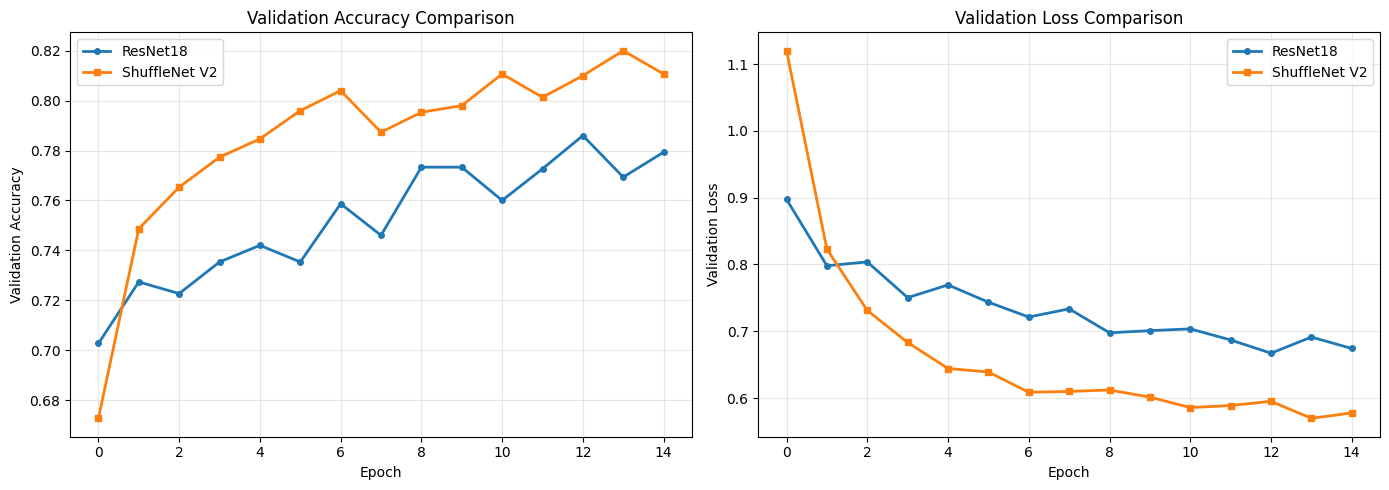

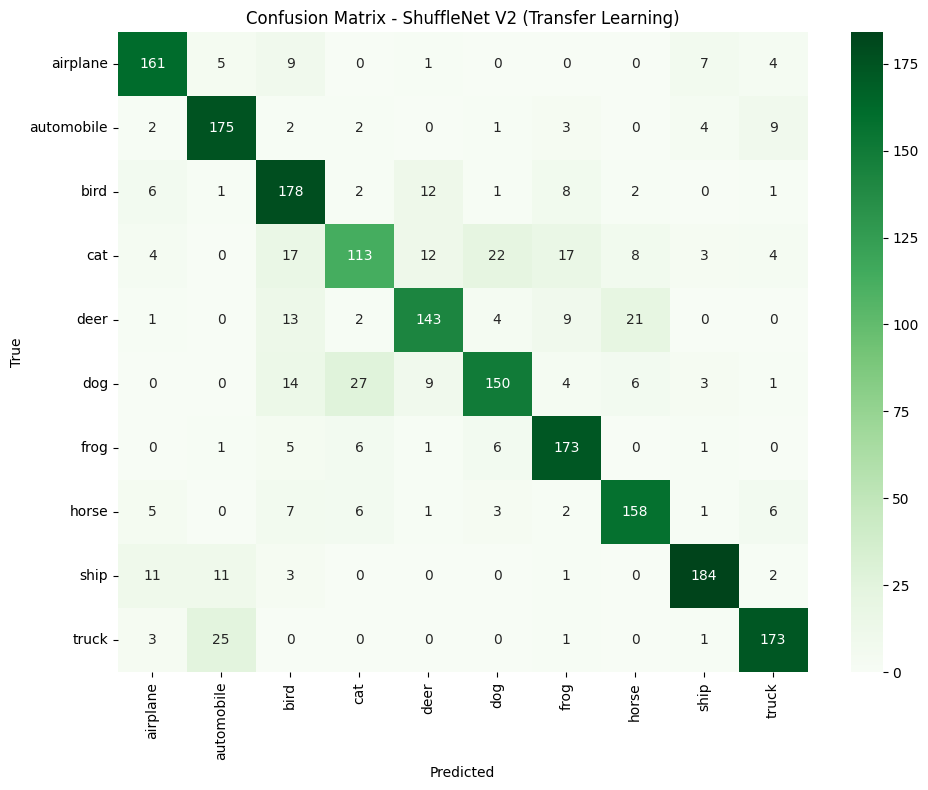


F1-Score per class (ShuffleNet V2):
  airplane    : 0.8474
  automobile  : 0.8413
  bird        : 0.7756
  cat         : 0.6313
  deer        : 0.7688
  dog         : 0.7481
  frog        : 0.8418
  horse       : 0.8229
  ship        : 0.8846
  truck       : 0.8586
  Macro Avg   : 0.8020


In [20]:
resnet_test_loss, resnet_test_acc = evaluate(resnet_model, test_loader_tl, nn.CrossEntropyLoss(), device)
shufflenet_test_loss, shufflenet_test_acc = evaluate(shufflenet_model, test_loader_tl, nn.CrossEntropyLoss(), device)


print(f"{'model':<20} {'Val Acc':>12} {'Test Acc':>12} {'Test Loss':>12}")
print("-" * 70)
print(f"{'ResNet18':<20} {resnet_best_acc:>12.4f} {resnet_test_acc:>12.4f} {resnet_test_loss:>12.4f}")
print(f"{'ShuffleNet V2':<20} {shufflenet_best_acc:>12.4f} {shufflenet_test_acc:>12.4f} {shufflenet_test_loss:>12.4f}")



fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation Accuracy
axes[0].plot(resnet_history["val_acc"], label="ResNet18", linewidth=2, marker="o", markersize=4)
axes[0].plot(shufflenet_history["val_acc"], label="ShuffleNet V2", linewidth=2, marker="s", markersize=4)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation Accuracy")
axes[0].set_title("Validation Accuracy Comparison")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation Loss
axes[1].plot(resnet_history["val_loss"], label="ResNet18", linewidth=2, marker="o", markersize=4)
axes[1].plot(shufflenet_history["val_loss"], label="ShuffleNet V2", linewidth=2, marker="s", markersize=4)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Loss")
axes[1].set_title("Validation Loss Comparison")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



if resnet_test_acc > shufflenet_test_acc:
    better = "ResNet18"
    diff = (resnet_test_acc - shufflenet_test_acc) * 100
else:
    better = "ShuffleNet V2"
    diff = (shufflenet_test_acc - resnet_test_acc) * 100


y_pred_better, y_true_better = get_predictions_temp(
    resnet_model if better == "ResNet18" else shufflenet_model, test_loader_tl, device
)

cm_tl = confusion_matrix(y_true_better, y_pred_better)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_tl, annot=True, fmt="d", cmap="Greens", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix - {better} (Transfer Learning)")
plt.tight_layout()
plt.show()


f1_tl = f1_score(y_true_better, y_pred_better, average=None)
print(f"\nF1-Score per class ({better}):")
for i, name in enumerate(class_names):
    print(f"  {name:<12}: {f1_tl[i]:.4f}")
print(f"  {'Macro Avg':<12}: {f1_tl.mean():.4f}")


### Analysis

Contrary to the conventional expectation that larger models transfer better, ShuffleNet V2 (×1.0) outperformed ResNet18 on this CIFAR-10 transfer learning task, achieving a best validation accuracy of **82.00%** (epoch 14) compared to ResNet18's best of **78.60%** (epoch 13) — a margin of +3.4%. ShuffleNet V2 also attained a lower validation loss (0.5695 vs. 0.6671) and higher training accuracy (75.98% vs. 69.61% final), indicating it fit the downstream task more effectively despite having roughly 8.5× fewer backbone parameters (~1.3M vs. ~11.2M). This counter-intuitive result is best explained by a resolution mismatch between ImageNet-pretrained architectures and CIFAR-10's tiny 32×32 images. ResNet18's stem uses a 7×7 convolution with stride 2 followed by 3×3 max-pooling (also stride 2), aggressively downsampling a 32×32 input to a mere 8×8 feature map — this leaves only 64 spatial positions, discarding fine-grained texture and shape details critical for distinguishing CIFAR-10 classes (e.g., bird vs. airplane, cat vs. dog). In contrast, ShuffleNet V2's stem uses a gentler 3×3 stride-1 convolution followed by more gradual downsampling across stages, preserving higher spatial resolution in its intermediate feature maps and thus retaining more discriminative details from low-resolution inputs. Additionally, ShuffleNet V2's channel split and channel shuffle operations create an implicit form of feature diversity that appears well-suited to CIFAR-10's limited visual complexity — the model learns a more compressed yet expressive representation where each channel carries greater information density. ResNet18, by contrast, may produce redundant or overly generic features from its large-capacity backbone, many of which are tuned to textures and patterns at ImageNet's 224×224 scale and contribute noise rather than signal when applied to 32×32 images with a frozen feature extractor. In summary, for frozen-backbone transfer learning on CIFAR-10, ShuffleNet V2's resolution-friendly stem design and parameter-efficient feature encoding proved more effective than ResNet18's deeper but spatially aggressive architecture.